<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_3_WorkGroupDataMinning/blob/main/Week02/ClassExercise/Exercise01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
# Crear un DataFrame de ejemplo con valores faltantes
data = {
    'A': [1, 2, None, 4, 5],
    'B': [None, 2, 3, 4, 5],
    'C': [1, 2, 3, None, 5]}
df = pd.DataFrame(data)

# Mostrar el DataFrame original
print("DataFrame original:")
print(df)

# Reemplazar NaN con la media de cada columna
df = df.fillna(df.mean())

# Mostrar el DataFrame después del preprocesamiento
print("\nDataFrame después del preprocesamiento:")
print(df)

DataFrame original:
     A    B    C
0  1.0  NaN  1.0
1  2.0  2.0  2.0
2  NaN  3.0  3.0
3  4.0  4.0  NaN
4  5.0  5.0  5.0

DataFrame después del preprocesamiento:
     A    B     C
0  1.0  3.5  1.00
1  2.0  2.0  2.00
2  3.0  3.0  3.00
3  4.0  4.0  2.75
4  5.0  5.0  5.00


In [2]:
import pandas as pd

# Crear un DataFrame de ejemplo con valores atípicos
data = {
    'A': [1, 2, 3, 4, 5, 1000], # Valor atípico: 1000
    'B': [10, 20, 30, 40, 50, 100] # Sin valores atípicos
    }
df = pd.DataFrame(data)

# Mostrar el DataFrame original
print("DataFrame original:")
print(df)


# Función para eliminar outliers usando el rango intercuartílico (IQR)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Eliminar outliers en la columna 'A'
df_no_outliers = remove_outliers_iqr(df, 'A')

# Mostrar el DataFrame después de eliminar outliers
print("\nDataFrame después de eliminar outliers:")
print(df_no_outliers)

DataFrame original:
      A    B
0     1   10
1     2   20
2     3   30
3     4   40
4     5   50
5  1000  100

DataFrame después de eliminar outliers:
   A   B
0  1  10
1  2  20
2  3  30
3  4  40
4  5  50


Primeras filas del DataFrame:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


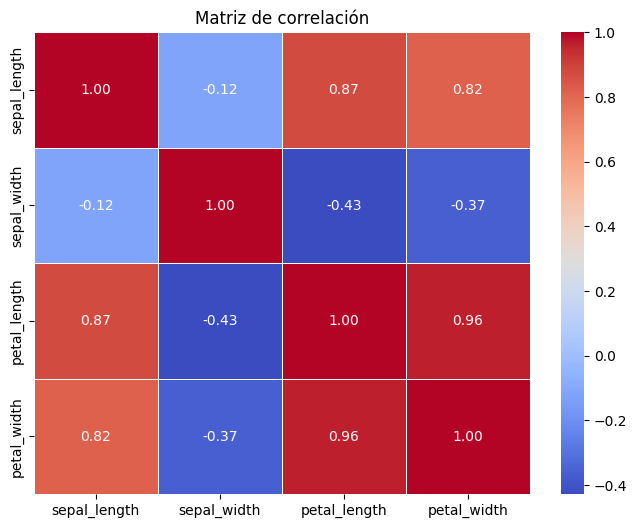

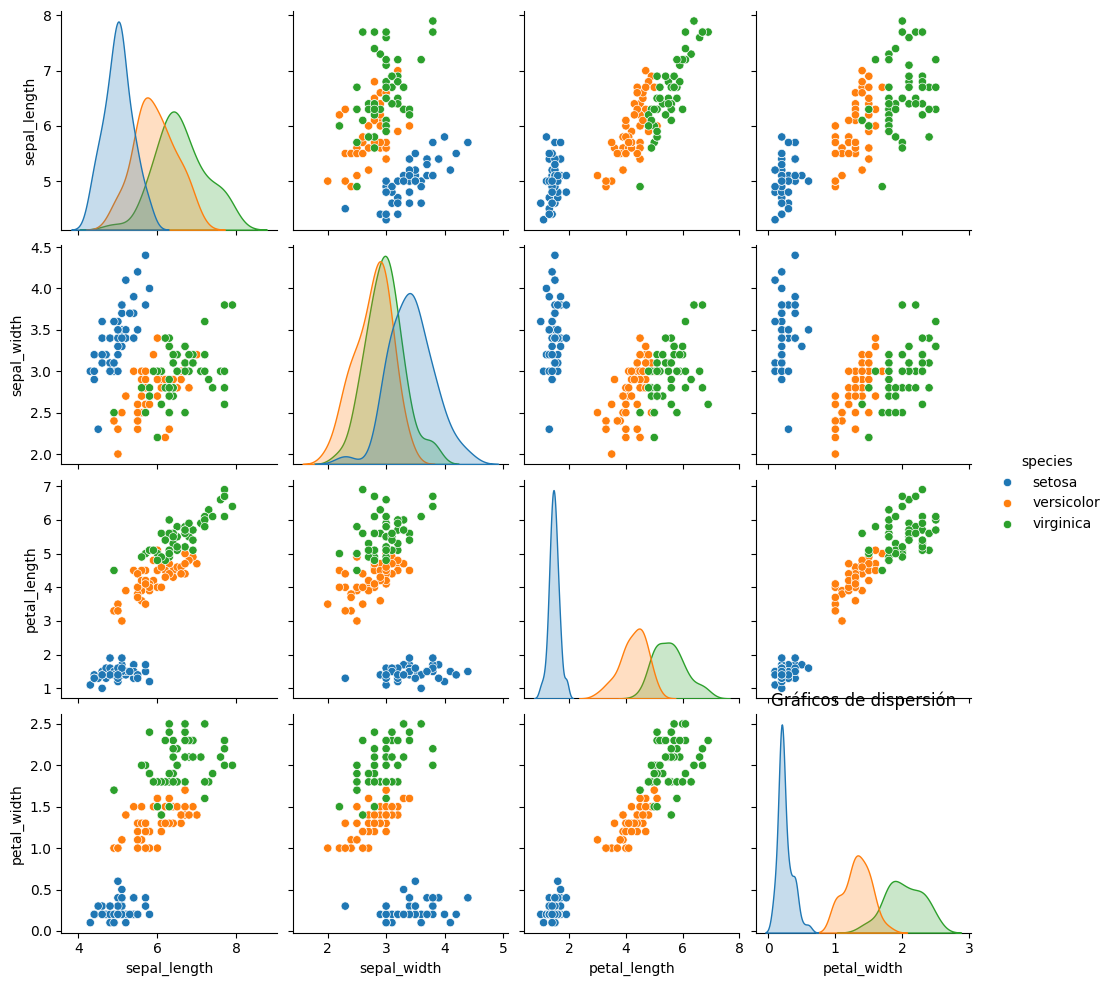

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el conjunto de datos de ejemplo
df = sns.load_dataset('iris')

# Mostrar las primeras filas del DataFrame
print("Primeras filas del DataFrame:")
print(df.head())

# Matriz de correlación
# Excluir la columna 'species' que contiene valores no numéricos
correlation_matrix = df.drop('species', axis=1).corr()

# Visualizar la matriz de correlación como un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de correlación")
plt.show()

# Gráficos de dispersión entre pares de variables
sns.pairplot(df, diag_kind='kde', hue='species')
plt.title("Gráficos de dispersión")
plt.show()

In [4]:
# Crear un DataFrame de ejemplo con variables categóricas
data = {'Color': ['Rojo', 'Verde', 'Azul', 'Rojo', 'Verde']}
df = pd.DataFrame(data)

# Codificación one-hot
df_encoded = pd.get_dummies(df['Color'])

print("DataFrame original:")
print(df)

print("\nDataFrame codificado:")
print(df_encoded)

DataFrame original:
   Color
0   Rojo
1  Verde
2   Azul
3   Rojo
4  Verde

DataFrame codificado:
    Azul   Rojo  Verde
0  False   True  False
1  False  False   True
2   True  False  False
3  False   True  False
4  False  False   True


# Agrupamiento de Clientes de un Centro Comercial con KMeans


In [5]:
# Importamos los paquetes necesarias
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
%matplotlib inline

# Cargamos la base de datos
# Define el nombre del archivo csv que se descargará
mall_customers = 'mall_customers.csv'

# Descarga el archivo csv del dataset
# El archivo se guarda en el entorno de trabajo actual y valido que si existe no lo descargue de nuevo

if not os.path.exists(mall_customers) and not os.path.exists(mall_customers):
  !wget --timeout=15 --tries=2 'https://raw.githubusercontent.com/ChrisJavier/UIDE_3_WorkGroupDataMinning/refs/heads/main/Week02/ClassExercise/Mall_Customers.csv' -O '{mall_customers}'
  print(f'Archivo {mall_customers} descargado')
else:
  print(f'Archivo {mall_customers} ya existe')

# Cargamos la base de datos 'mall_customers.csv'
clientes = pd.read_csv('mall_customers.csv')

--2026-07-18 23:48:24--  https://raw.githubusercontent.com/ChrisJavier/UIDE_3_WorkGroupDataMinning/refs/heads/main/Week02/ClassExercise/Mall_Customers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4286 (4.2K) [text/plain]
Saving to: ‘mall_customers.csv’

mall_customers.csv  100%[===================>]   4.19K  --.-KB/s    in 0s      

2026-07-18 23:48:24 (43.7 MB/s) - ‘mall_customers.csv’ saved [4286/4286]

Archivo mall_customers.csv descargado


In [6]:
# Visualizamos los primeros registros
clientes.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [7]:
# Eliminamos la columna 'CustomerID'
clientes = clientes.drop('CustomerID', axis=1)
clientes.head(10)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
5,Female,22,17,76
6,Female,35,18,6
7,Female,23,18,94
8,Male,64,19,3
9,Female,30,19,72


In [8]:
# Visualizamos la información de la base de datos
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Genre                   200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [9]:
# Visualizamos la descripción de la base de datos
clientes.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [10]:
# Codificamos la variable 'Genre'
clientes['Genre'] = clientes['Genre'].replace({'Female': 0, 'Male': 1})
clientes.head(10)

/tmp/ipykernel_982/1794219564.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clientes['Genre'] = clientes['Genre'].replace({'Female': 0, 'Male': 1})


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
5,0,22,17,76
6,0,35,18,6
7,0,23,18,94
8,1,64,19,3
9,0,30,19,72


In [11]:
# Agrupamiento de Clientes de un Centro Comercial con KMeans - Contenido
# Instalamos la librería ydata_profiling
!pip install ydata_profiling

# Importamos ProfileReport de la librería ydata_profiling
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.8 MB/s eta 0:00:00


/tmp/ipykernel_982/4064282275.py:6: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [12]:
# Generamos el reporte de perfilado de datos
perfil_datos = ProfileReport(clientes, title='Reporte de Perfilado de Datos')

# Generamos el reporte en formato HTML
print("Intentando generar el reporte HTML...")
perfil_datos.to_file("reporte_perfilado.html")
print("El reporte HTML ha sido generado como 'reporte_perfilado.html'.")
print("Por favor, revisa el panel de archivos de Colab (icono de carpeta) para descargarlo.")

Intentando generar el reporte HTML...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 258.80it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

El reporte HTML ha sido generado como 'reporte_perfilado.html'.
Por favor, revisa el panel de archivos de Colab (icono de carpeta) para descargarlo.


In [13]:
from IPython.display import HTML

# Leemos el contenido del archivo HTML generado
with open('reporte_perfilado.html', 'r') as f:
    html_content = f.read()

# Mostramos el contenido HTML en la salida de la celda
HTML(html_content)

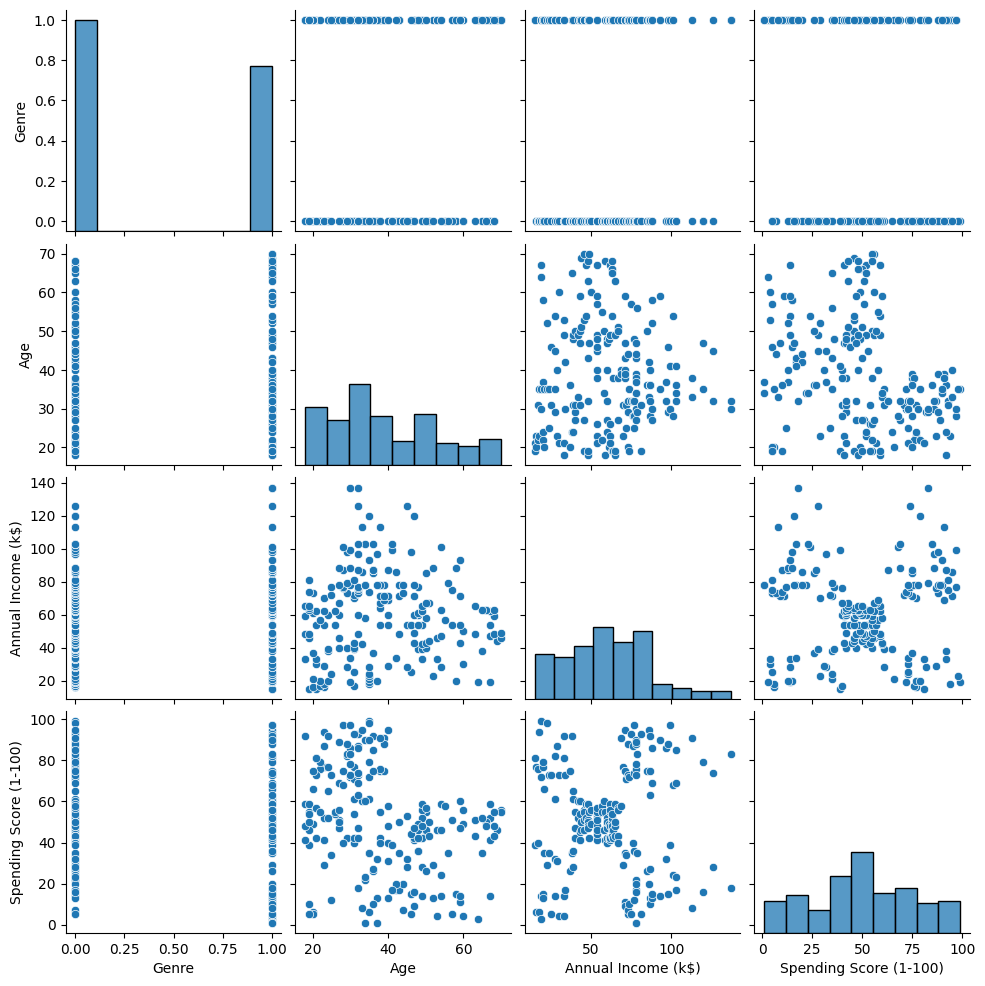

In [14]:
# Graficamos la distribución de todas las variables
sns.pairplot(clientes)

In [15]:
# Creamos un DataFrame solamente con las columnas 'Annual Income (k$)' y 'Spending Score (1-100)'
income_spending = clientes[['Annual Income (k$)', 'Spending Score (1-100)']].copy()
income_spending.head(10)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
5,17,76
6,18,6
7,18,94
8,19,3
9,19,72


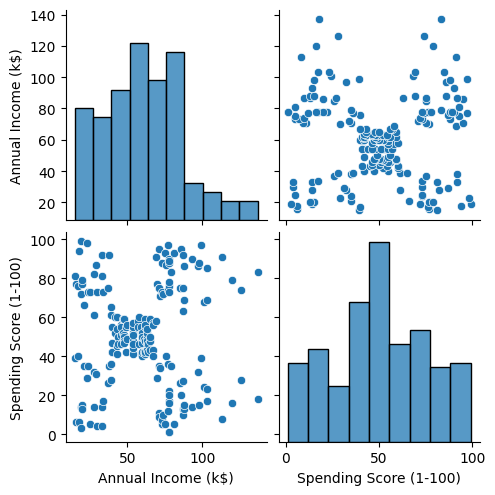

In [16]:
# Graficamos la distribución de income_spending
sns.pairplot(income_spending)

In [17]:
# Instanciamos el modelo KMeans
modelo_kmeans = KMeans(n_clusters=2)

# Ajustamos el modelo a los datos
modelo_kmeans.fit(income_spending)

# Duplicamos la base de datos 'income_spending' para no modificar la original
income_spending_cluster = income_spending.copy()

# Obtenemos las etiquetas de los clusters asignados a cada cliente
income_spending_cluster['Cluster'] = modelo_kmeans.labels_

# Visualizamos los primeros registros de 'income_spending_cluster'
income_spending_cluster.head(10)

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,0
1,15,81,0
2,16,6,0
3,16,77,0
4,17,40,0
5,17,76,0
6,18,6,0
7,18,94,0
8,19,3,0
9,19,72,0


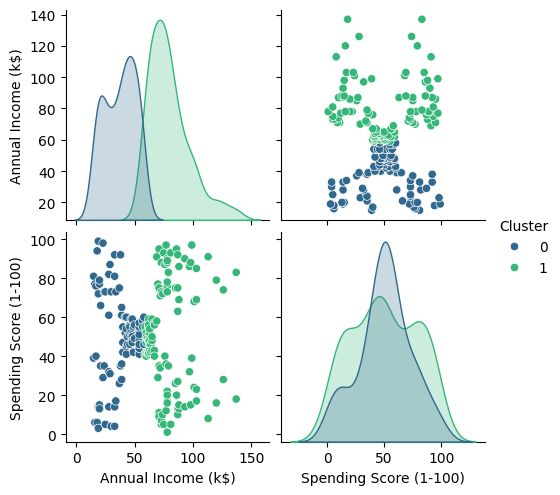

In [18]:
# Visualizamos los clusters generados por el modelo KMeans
sns.pairplot(income_spending_cluster, hue='Cluster', palette='viridis')

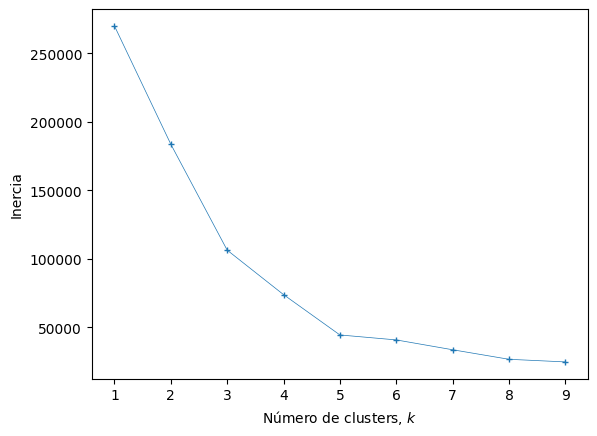

In [19]:
# Definimos un rango de números del 1 al 9 para representar los posibles núm
ks = range(1, 10)
# Creamos una lista vacía para almacenar los valores de inercia para cada número k
inercias = []
# Iteramos sobre cada número en el rango ks
for k in ks:
    # Creamos una instancia del algoritmo KMeans con clusters
    model = KMeans(n_clusters=k, random_state=42)
    # Ajustamos el modelo a los datos contenidos en
    income_spending
    model.fit(income_spending)
    # Añadimos el valor de la inercia del modelo a la lista inercias
    inercias.append(model.inertia_)
# Graficamos los valores de inercia en función del número de clusters
plt.plot(ks, inercias, marker='+', linewidth=0.5, markersize=5)
# Establecemos la etiqueta del eje x
plt.xlabel('Número de clusters, $k$')
# Establecemos la etiqueta del eje y
plt.ylabel('Inercia')
# Establecemos las marcas del eje x para que coincidan con los números de cl
plt.xticks(ks)
# Mostramos el gráfico
plt.show()

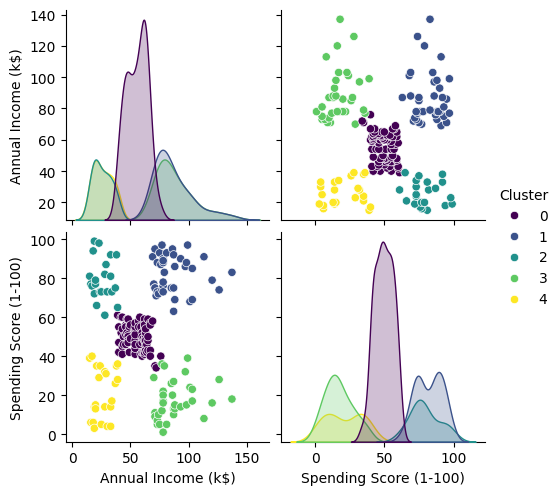

In [20]:
# Instanciamos el modelo KMeans
modelo_kmeans = KMeans(n_clusters=5, random_state=42)
# Ajustamos el modelo a los datos, utilizando solo las columnas de interés para el clustering
modelo_kmeans.fit(income_spending[['Annual Income (k$)', 'Spending Score (1-100)']])
# Obtenemos las etiquetas de los clusters asignados a cada cliente
income_spending['Cluster'] = modelo_kmeans.labels_
income_spending.head(10)
# Visualizamos los clusters
sns.pairplot(income_spending, hue='Cluster', palette='viridis')

In [21]:
# Creamos los datos de un nuevo cliente (ingresos anuales, puntuación de gasto)
cliente_nuevo = [40, 60]

# Hacemos una predicción con el modelo KMeans para el nuevo cliente
cluster_nuevo = modelo_kmeans.predict([cliente_nuevo])
print('El nuevo cliente pertenece al cluster:', cluster_nuevo)

El nuevo cliente pertenece al cluster: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


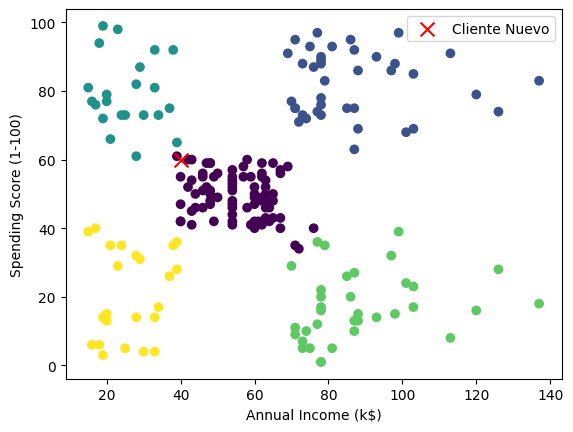

In [22]:
# Visualizamos los datos del cliente nuevo en el espacio de las variables
plt.scatter(income_spending['Annual Income (k$)'], income_spending['Spending Score (1-100)'], c=income_spending['Cluster'], cmap='viridis')
plt.scatter(cliente_nuevo[0], cliente_nuevo[1], c='red', marker='x', s=100, label='Cliente Nuevo')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Procesamiento y Transformación de Datos para Análisis de Crédito

In [27]:
import numpy as np

# Cargamos la base de datos
# Define el nombre del archivo csv que se descargará
credit_score = 'credit_score.csv'

# Descarga el archivo csv del dataset
# El archivo se guarda en el entorno de trabajo actual y valido que si existe no lo descargue de nuevo

if not os.path.exists(credit_score) and not os.path.exists(credit_score):
  !wget --timeout=15 --tries=2 'https://raw.githubusercontent.com/ChrisJavier/UIDE_3_WorkGroupDataMinning/refs/heads/main/Week02/ClassExercise/credit_score.csv' -O '{credit_score}'
  print(f'Archivo {credit_score} descargado')
else:
  print(f'Archivo {credit_score} ya existe')

# Cargamos la base de datos 'credit_score.csv'
data = pd.read_csv('credit_score.csv')
data.head(10)

Archivo credit_score.csv ya existe


/tmp/ipykernel_982/4088201706.py:17: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('credit_score.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


In [28]:
# Mostramos la información de la base de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [29]:
# Mostramos la cantidad de registros y columnas de la base de datos
data.describe(exclude=np.number).T

,count,unique,top,freq
ID,100000,100000,0x25fd5,1
Customer_ID,100000,12500,CUS_0x942c,8
Month,100000,8,January,12500
Name,90015,10139,Stevex,44
Age,100000,1788,38,2833
SSN,100000,12501,#F%$D@*&8,5572
Occupation,100000,16,_______,7062
Annual_Income,100000,18940,36585.12,16
Num_of_Loan,100000,434,3,14386
Type_of_Loan,88592,6260,Not Specified,1408


In [31]:
# Identificar valores faltantes
missing_values = data.isnull().sum()
missing_values

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


In [32]:
# Mostramos el porcentaje de valores faltantes
data.isnull().mean()*100

,0
ID,0.000
Customer_ID,0.000
Month,0.000
Name,9.985
Age,0.000
SSN,0.000
Occupation,0.000
Annual_Income,0.000
Monthly_Inhand_Salary,15.002
Num_Bank_Accounts,0.000


In [33]:
# Eliminamos columnas que no aportan información relevante para el análisis
data = data.drop(['ID', 'SSN', 'Customer_ID', 'Name', 'Month'], axis=1)
data.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,-500,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [34]:
# Mostramos los valores únicos de la columna 'Age'
print(list(data['Age'].unique()))

['23', '-500', '28_', '28', '34', '54', '55', '21', '31', '33', '34_', '7580', '30', '30_', '24', '24_', '44', '45', '40', '41', '32', '33_', '35', '35_', '36', '39', '37', '181', '20', '46', '26', '42', '19', '31_', '48', '995', '40_', '37_', '38', '54_', '5079', '43', '21_', '22', '6409', '16', '7080', '18', '849', '3885', '20_', '15', '27', '43_', '38_', '25', '3052', '14', '5342', '17', '18_', '4431', '2657', '2111_', '46_', '47', '1032', '16_', '19_', '47_', '456', '5717', '53_', '53', '56', '25_', '27_', '55_', '3169', '1191', '29', '42_', '7140', '48_', '49', '49_', '8233', '6955', '2534', '3115', '7657', '51', '50', '5112', '50_', '32_', '6452', '2744', '22_', '17_', '1439', '29_', '5795', '4872', '1772', '15_', '1383', '5657', '52', '1934', '51_', '8352', '3734', '26_', '2056', '39_', '7508', '2339', '14_', '8406', '1424', '36_', '6953', '5626', '4471', '548', '44_', '769', '5490', '525', '4202', '3665', '7670_', '4670', '3616', '6922', '6619', '1808', '7992', '45_', '223', '1

In [37]:
# Substituimos los valores '_' por '' y los convertimos a tipo flotante ('float')
data['Age'] = data['Age'].replace('_', '', regex=True).astype('float')

# Definimos un rango para los valores de la columna 'Age' de 1:100 y sustituimos los restantes con 'nan'
data.loc[data.Age < 1, 'Age'] = np.nan
data.loc[data.Age > 100, 'Age'] = np.nan

# Reemplazamos los valores 'nan' de la columna 'Age' con la media de la misma
data['Age'] = data['Age'].fillna(data['Age'].mean())

# Mostramos los valores únicos de la columna 'Age'
print(list(data['Age'].unique()))

# Mostramos el tipo de la columna 'Age'
print(data['Age'].dtype)

[np.float64(23.0), np.float64(33.32327408870238), np.float64(28.0), np.float64(34.0), np.float64(54.0), np.float64(55.0), np.float64(21.0), np.float64(31.0), np.float64(33.0), np.float64(30.0), np.float64(24.0), np.float64(44.0), np.float64(45.0), np.float64(40.0), np.float64(41.0), np.float64(32.0), np.float64(35.0), np.float64(36.0), np.float64(39.0), np.float64(37.0), np.float64(20.0), np.float64(46.0), np.float64(26.0), np.float64(42.0), np.float64(19.0), np.float64(48.0), np.float64(38.0), np.float64(43.0), np.float64(22.0), np.float64(16.0), np.float64(18.0), np.float64(15.0), np.float64(27.0), np.float64(25.0), np.float64(14.0), np.float64(17.0), np.float64(47.0), np.float64(53.0), np.float64(56.0), np.float64(29.0), np.float64(49.0), np.float64(51.0), np.float64(50.0), np.float64(52.0), np.float64(99.0), np.float64(100.0), np.float64(95.0)]
float64


In [38]:
# Revisamos que no haya valores faltantes y que el tipo de dato de la columna
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Occupation                100000 non-null  object 
 2   Annual_Income             100000 non-null  object 
 3   Monthly_Inhand_Salary     84998 non-null   float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  object 
 8   Type_of_Loan              88592 non-null   object 
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    92998 non-null   object 
 11  Changed_Credit_Limit      100000 non-null  object 
 12  Num_Credit_Inquiries      98035 non-null   float64
 13  Credit_Mix                100000 non-null  ob

In [39]:
# Mostramos los valores únicos de la columna 'Occupation'
print(list(data['Occupation'].unique()))

['Scientist', '_______', 'Teacher', 'Engineer', 'Entrepreneur', 'Developer', 'Lawyer', 'Media_Manager', 'Doctor', 'Journalist', 'Manager', 'Accountant', 'Musician', 'Mechanic', 'Writer', 'Architect']


In [40]:
# Substituimos el valor '_______' por 'nan' y los convertimos a tipo flotante ('float')
data['Occupation'] = data['Occupation'].replace('_______', np.nan, regex=True)

# Mostramos el número e valores 'nan' en la columna 'Occupation'
print(data['Occupation'].isna().sum())

7062


In [42]:
# Calculamos la moda
mode = data['Occupation'].mode()[0]
mode

'Lawyer'

In [43]:
# Reemplazamos los valores NaN con la moda
data['Occupation'].fillna(mode, inplace=True)

/tmp/ipykernel_982/2445284803.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Occupation'].fillna(mode, inplace=True)


In [44]:
# Eliminamos los registros con valores NaN en la columna 'Occupation'
data.dropna(subset=['Occupation'], inplace=True)

In [45]:
# Eliminar columnas del DataFrame 'data' con más del 70% de valores faltante
threshold = int(len(data) * 0.7)
data = data.dropna(thresh=threshold, axis=1)

In [47]:
# Codificación de etiquetas (Label Encoding) para la columna 'Occupation'

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['Occupation'] = label_encoder.fit_transform(data['Occupation'])
data.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23.000000,12,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,23.000000,12,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,33.323274,12,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,23.000000,12,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,23.000000,12,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [48]:
# Revisamos que no haya valores faltantes y que el tipo de dato de la columna
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Occupation                100000 non-null  int64  
 2   Annual_Income             100000 non-null  object 
 3   Monthly_Inhand_Salary     84998 non-null   float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  object 
 8   Type_of_Loan              88592 non-null   object 
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    92998 non-null   object 
 11  Changed_Credit_Limit      100000 non-null  object 
 12  Num_Credit_Inquiries      98035 non-null   float64
 13  Credit_Mix                100000 non-null  ob

In [54]:
from sklearn.preprocessing import StandardScaler

# Limpiar y convertir 'Annual_Income' a tipo numérico
data['Annual_Income'] = data['Annual_Income'].replace('[^0-9.]', '', regex=True).astype(float)

# Limpiar y convertir 'Outstanding_Debt' a tipo numérico
data['Outstanding_Debt'] = data['Outstanding_Debt'].replace('[^0-9.]', '', regex=True).astype(float)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[['Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt']])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Occupation                100000 non-null  int64  
 2   Annual_Income             100000 non-null  float64
 3   Monthly_Inhand_Salary     84998 non-null   float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  object 
 8   Type_of_Loan              88592 non-null   object 
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    92998 non-null   object 
 11  Changed_Credit_Limit      100000 non-null  object 
 12  Num_Credit_Inquiries      98035 non-null   float64
 13  Credit_Mix                100000 non-null  ob

In [56]:
# Lista de columnas que necesitan limpieza y conversión a numérico
columns_to_clean = [
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in columns_to_clean:
    # Rellenar NaN temporales si la columna podría contenerlos antes de la limpieza
    # Aunque el .replace por regex ya lo manejaría bien con NaN
    if data[col].dtype == 'object':
        # Eliminar cualquier carácter que no sea dígito, punto o guion (para números negativos)
        data[col] = data[col].astype(str).str.replace('[^0-9.-]', '', regex=True)
        # Convertir a float y manejar errores con coerce, los errores se convertirán en NaN
        data[col] = pd.to_numeric(data[col], errors='coerce')
    # Rellenar los NaN resultantes de la conversión o preexistentes con la media de la columna
    data[col] = data[col].fillna(data[col].mean())

# Ahora que las columnas problemáticas han sido limpiadas y convertidas a tipo numérico,
# podemos calcular la matriz de correlación.
correlation = data.corr(numeric_only=True)
correlation

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
Age,1.000000,-0.005199,0.006375,0.087579,-0.000358,-0.005778,-0.001373,-0.009052,-0.171188,0.001214,-0.152877,-0.005892,-0.199530,0.024681,0.001013,0.005330,-0.001680
Occupation,-0.005199,1.000000,-0.002747,0.002004,-0.006159,-0.004266,0.003990,0.001614,0.007408,0.003777,-0.001383,-0.002708,0.006871,0.000743,-0.001481,0.004434,0.003966
Annual_Income,0.006375,-0.002747,1.000000,0.030519,-0.004627,0.001250,-0.002908,0.001464,-0.010631,0.001135,0.000606,0.003153,-0.003706,0.010316,-0.000248,-0.005213,0.000811
Monthly_Inhand_Salary,0.087579,0.002004,0.030519,1.000000,-0.010819,-0.005049,-0.006422,-0.010398,-0.250100,0.000884,-0.173062,-0.008867,-0.269727,0.173192,0.007264,0.060118,-0.000790
Num_Bank_Accounts,-0.000358,-0.006159,-0.004627,-0.010819,1.000000,-0.002216,-0.003998,-0.000679,0.015966,-0.003488,0.007910,-0.001683,0.015548,-0.001365,-0.001433,0.003156,0.001062
Num_Credit_Card,-0.005778,-0.004266,0.001250,-0.005049,-0.002216,1.000000,-0.004012,0.001421,0.008715,0.004704,0.005547,-0.003479,0.005626,-0.003341,0.000768,-0.002018,0.001269
Interest_Rate,-0.001373,0.003990,-0.002908,-0.006422,-0.003998,-0.004012,1.000000,0.000614,0.009792,0.002592,0.000878,-0.001681,0.010721,-0.000359,0.002517,-0.001177,0.001249
Num_of_Loan,-0.009052,0.001614,0.001464,-0.010398,-0.000679,0.001421,0.000614,1.000000,0.012625,0.009896,0.015642,-0.000497,0.023772,-0.003967,0.001554,-0.000832,-0.000033
Delay_from_due_date,-0.171188,0.007408,-0.010631,-0.250100,0.015966,0.008715,0.009792,0.012625,1.000000,0.012203,0.290707,0.011508,0.571713,-0.063796,-0.003889,-0.012278,0.004422
Num_of_Delayed_Payment,0.001214,0.003777,0.001135,0.000884,-0.003488,0.004704,0.002592,0.009896,0.012203,1.000000,0.006813,0.002719,0.009755,0.000835,0.001081,0.001212,0.000927


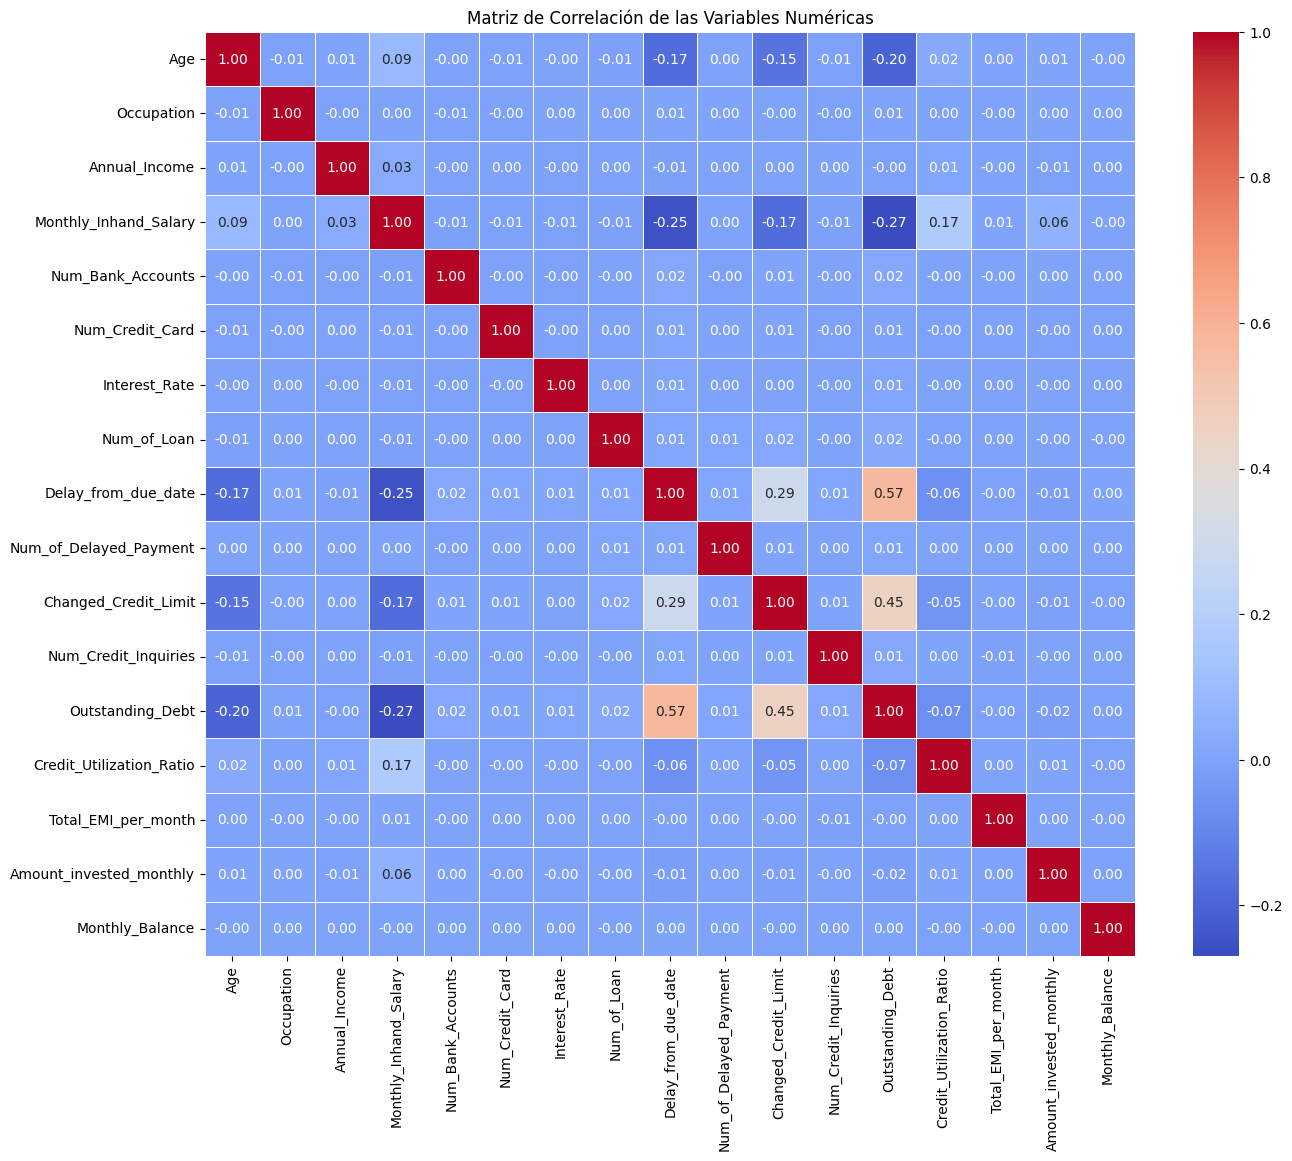

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12)) # Ajusta el tamaño de la figura para una mejor visibilidad
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de las Variables Numéricas')
plt.show()